In [42]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [43]:
from pathlib import Path
import os

print("📍 Current working directory:", os.getcwd())

df = pd.read_csv("../data/raw/Employee.csv")
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [44]:
df.shape, df.columns

((4653, 9),
 Index(['Education', 'JoiningYear', 'City', 'PaymentTier', 'Age', 'Gender',
        'EverBenched', 'ExperienceInCurrentDomain', 'LeaveOrNot'],
       dtype='str'))

In [45]:
df["LeaveOrNot"].value_counts(normalize=True)

LeaveOrNot
0    0.656136
1    0.343864
Name: proportion, dtype: float64

In [46]:
TARGET = "LeaveOrNot"

X = df.drop(columns=[TARGET])
y = df[TARGET]

X.shape, y.shape

((4653, 8), (4653,))

In [47]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

cat_cols, num_cols

(['Education', 'City', 'Gender', 'EverBenched'],
 ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain'])

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((3489, 8), (1164, 8))

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

model = LogisticRegression(max_iter=2000)

pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", model)
])

pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [50]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.7465635738831615


In [51]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[684,  80],
       [215, 185]])

In [52]:
print(classification_report(y_test, y_pred, target_names=["No Leave", "Leave"]))

              precision    recall  f1-score   support

    No Leave       0.76      0.90      0.82       764
       Leave       0.70      0.46      0.56       400

    accuracy                           0.75      1164
   macro avg       0.73      0.68      0.69      1164
weighted avg       0.74      0.75      0.73      1164



In [53]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", auc)

ROC AUC: 0.7324329188481675


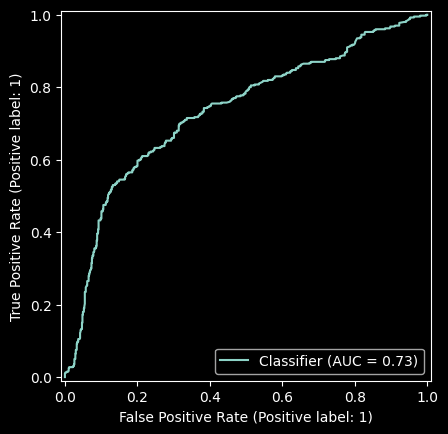

In [54]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"  # très important en churn
)

rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", rf_model)
])

In [57]:
rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))
print(classification_report(y_test, rf_pred, target_names=["No Leave", "Leave"]))

Accuracy: 0.8195876288659794
ROC AUC: 0.8537336387434555
              precision    recall  f1-score   support

    No Leave       0.84      0.89      0.87       764
       Leave       0.77      0.68      0.72       400

    accuracy                           0.82      1164
   macro avg       0.81      0.79      0.79      1164
weighted avg       0.82      0.82      0.82      1164



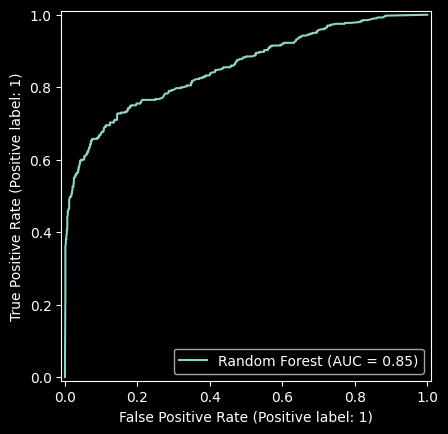

In [58]:
RocCurveDisplay.from_predictions(y_test, y_proba, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest")
plt.show()